In [21]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import time
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from quantum_walk.community_detection_qw import create_walk_operator, run_walk, top_k_degree_vertices

N_NODES_LIST = np.arange(5,20,1)  # extend as needed
K            = 4
N_RUNS       = 10
SEED_GRAPH   = 10
EPSILON      = 1e-4
MAX_STEPS    = 5000
MIN_STEPS    = 50

In [22]:
def get_gnp_graph(n, seed):
    s = seed
    while True:
        G = nx.gnp_random_graph(n, p=0.15, seed=s)
        if nx.is_connected(G):
            return G
        s += 1

In [23]:
rng   = np.random.default_rng(SEED_GRAPH)
seeds = rng.integers(0, 10000, size=N_RUNS).tolist()

steps_results = {n: [] for n in N_NODES_LIST}
conv_flags    = {n: [] for n in N_NODES_LIST}

for n in N_NODES_LIST:
    print(f"\nn={n}")
    for s in seeds:
        G     = get_gnp_graph(n, seed=s)
        V_max = top_k_degree_vertices(G, K)

        walk_op  = create_walk_operator(G)
        walk_run = run_walk(walk_op, V_max, epsilon=EPSILON, max_steps=MAX_STEPS, min_steps=MIN_STEPS)

        steps_results[n].append(walk_run['steps_run'])
        conv_flags[n].append(walk_run['converged'])

        tag = "OK" if walk_run['converged'] else "CAP"
        print(f"  seed={s}: steps={walk_run['steps_run']} [{tag}]")


n=5
  seed=7765: steps=1237 [OK]
  seed=9560: steps=1414 [OK]
  seed=2640: steps=1413 [OK]
  seed=2076: steps=1237 [OK]
  seed=7925: steps=1237 [OK]
  seed=8284: steps=1413 [OK]
  seed=5147: steps=1414 [OK]
  seed=1492: steps=1370 [OK]
  seed=8328: steps=1219 [OK]
  seed=5128: steps=1414 [OK]

n=6
  seed=7765: steps=1323 [OK]
  seed=9560: steps=826 [OK]
  seed=2640: steps=1572 [OK]
  seed=2076: steps=1370 [OK]
  seed=7925: steps=1641 [OK]
  seed=8284: steps=762 [OK]
  seed=5147: steps=1572 [OK]
  seed=1492: steps=776 [OK]
  seed=8328: steps=821 [OK]
  seed=5128: steps=1572 [OK]

n=7
  seed=7765: steps=1038 [OK]
  seed=9560: steps=1260 [OK]
  seed=2640: steps=1157 [OK]
  seed=2076: steps=716 [OK]
  seed=7925: steps=1443 [OK]
  seed=8284: steps=637 [OK]
  seed=5147: steps=1443 [OK]
  seed=1492: steps=540 [OK]
  seed=8328: steps=840 [OK]
  seed=5128: steps=1443 [OK]

n=8
  seed=7765: steps=978 [OK]
  seed=9560: steps=1396 [OK]
  seed=2640: steps=1072 [OK]
  seed=2076: steps=1241 [OK]
  s

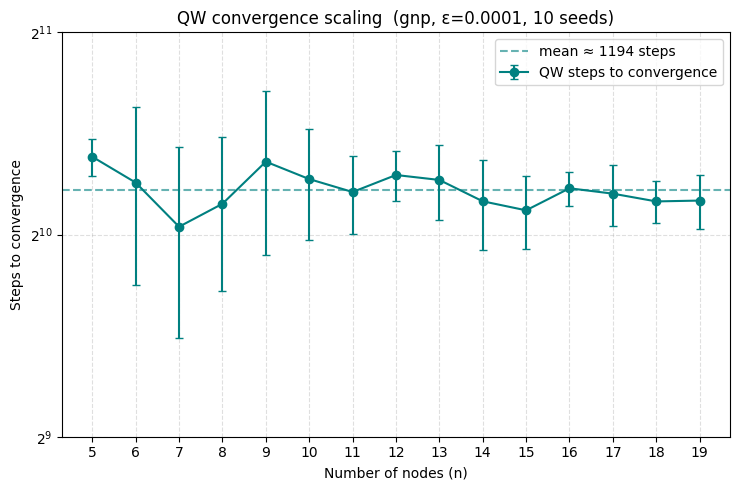

Convergence rates: {np.int64(5): np.float64(1.0), np.int64(6): np.float64(1.0), np.int64(7): np.float64(1.0), np.int64(8): np.float64(1.0), np.int64(9): np.float64(1.0), np.int64(10): np.float64(1.0), np.int64(11): np.float64(1.0), np.int64(12): np.float64(1.0), np.int64(13): np.float64(1.0), np.int64(14): np.float64(1.0), np.int64(15): np.float64(1.0), np.int64(16): np.float64(1.0), np.int64(17): np.float64(1.0), np.int64(18): np.float64(1.0), np.int64(19): np.float64(1.0)}
Mean steps across all sizes: 1194.2 ± 185.6


In [26]:
n_arr     = np.array(N_NODES_LIST)
step_mean = np.array([np.mean(steps_results[n]) for n in N_NODES_LIST])
step_std  = np.array([np.std(steps_results[n])  for n in N_NODES_LIST])

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.errorbar(n_arr, step_mean, yerr=step_std, fmt='o-', color='teal',
            capsize=3, linewidth=1.5, label='QW steps to convergence')
ax.axhline(step_mean.mean(), color='teal', linestyle='--', alpha=0.6,
           label=f'mean ≈ {step_mean.mean():.0f} steps')

ax.set_xlabel('Number of nodes (n)')
ax.set_ylabel('Steps to convergence')
ax.set_title(f'QW convergence scaling  (gnp, ε={EPSILON}, {N_RUNS} seeds)')
ax.set_xticks(n_arr)
ax.set_yscale('log', base=2)
ax.set_ylim(2**9, 2**11)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
fig.tight_layout()
plt.show()

conv_rates = {n: np.mean(conv_flags[n]) for n in N_NODES_LIST}
print(f"Convergence rates: {conv_rates}")
print(f"Mean steps across all sizes: {step_mean.mean():.1f} ± {step_std.mean():.1f}")
